# Setup

In [1]:
import scanpy
import matplotlib
from matplotlib import pyplot
import hdf5plugin
import numpy
import seaborn
import pandas
import warnings
import decoupler
import IPython
import single_cell_analysis

In [2]:
from importlib import reload

single_cell_analysis = reload(single_cell_analysis)

In [3]:
# Scanpy plotting setup

figure_size = (5, 5)
fontsize = 14
scanpy.set_figure_params(figsize=figure_size, dpi=100, color_map="plasma", frameon=True, fontsize=fontsize)
pyplot.rcParams.update({"axes.grid": False})
pyplot.rcParams["text.usetex"] = True
latex_preamble = r"\usepackage{DejaVuSans} \renewcommand{\familydefault}{\sfdefault} \usepackage{sansmath} \sansmath"
pyplot.rcParams["text.latex.preamble"] = latex_preamble

# Suppress warnings
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=matplotlib.MatplotlibDeprecationWarning)

In [4]:
# Read Cellrank adata and drivers

working_directory = "Data/"
base_name = "pv_cellrank_scvelo"
adata = scanpy.read_h5ad(working_directory+f"/{base_name}.h5ad")
driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes.csv",
    index_col=0
)
variable_driver_df = pandas.read_csv(
    working_directory+f"{base_name}_driver_genes_variable.csv",
    index_col=0
)

# Read TF list
tf_df = pandas.read_csv("Data/Homo_sapiens_TF.txt", sep="\t")
tf_array = tf_df["Symbol"].to_list()

In [5]:
# Load CollecTRI and run ULM in single cells

collectri_df = decoupler.op.collectri(organism="human")

# Remove unreliable signs
modified_collectri = collectri_df.query("sign_decision != 'default activation'")
# Remove autoregulation
modified_collectri = modified_collectri.query("not (source == target)")

# Define drivers

Criteria for drivers:

- Transcription factors
- High correlation with Cellrank fate probability
- Expressed in important clusters in the PV trajectory

In [6]:
# Run ULM in single cells and on driver_df

# Run ULM
decoupler.mt.ulm(
    data=adata,
    net=modified_collectri,
    tmin=5,
    raw=True
)

# TF activities among PV drivers
data = driver_df[["15_corr"]].T.dropna(axis=1)
tf_acts, tf_padj = decoupler.mt.ulm(data=data, net=modified_collectri, tmin=5)
ulm_driver_df = pandas.DataFrame(data={"Activity": tf_acts.transpose()["15_corr"], "Adjusted p-value": tf_padj.transpose()["15_corr"]}, index=tf_acts.columns)

In [7]:
# Find the 20 TFs that are most correlated with cluster 15 fate probability.

pv_drivers = driver_df.loc[numpy.intersect1d(ulm_driver_df.index, driver_df.index)].sort_values("15_corr", ascending=False).head(12).index.to_list()

print(f"PV drivers:\n{pv_drivers}")

PV drivers:
['HES1', 'NOTCH1', 'GLI3', 'GLIS3', 'WWTR1', 'NCOR2', 'YAP1', 'GLI2', 'TCF7L2', 'RREB1', 'BTG2', 'SOX6']


In [8]:
driver_df.loc[pv_drivers]

,3_corr,3_pval,3_qval,3_ci_low,3_ci_high,7.1_corr,7.1_pval,7.1_qval,7.1_ci_low,7.1_ci_high,15_corr,15_pval,15_qval,15_ci_low,15_ci_high
HES1,-0.173578,5.218235e-105,1.946257e-103,-0.188851,-0.158220,-0.001693,8.335330e-01,9.117695e-01,-0.017484,0.014098,0.285770,2.113109e-291,1.668532e-288,0.271203,0.300207
NOTCH1,-0.144270,1.114240e-72,2.753620e-71,-0.159697,-0.128772,-0.025087,1.844925e-03,5.674832e-03,-0.040861,-0.009299,0.277832,1.110056e-274,6.910949e-272,0.263196,0.292341
GLI3,-0.293832,5.596811e-309,1.104824e-306,-0.308193,-0.279337,0.118618,1.668910e-49,4.378386e-48,0.103020,0.134158,0.276936,7.889703e-273,4.730023e-270,0.262292,0.291452
GLIS3,-0.248105,4.438174e-217,4.490045e-215,-0.262866,-0.233228,0.080197,1.969560e-23,2.581480e-22,0.064488,0.095867,0.267810,2.179629e-254,1.102552e-251,0.253089,0.282407
WWTR1,-0.224333,1.782255e-176,1.364036e-174,-0.239276,-0.209283,0.060021,8.779077e-14,7.274477e-13,0.044272,0.075740,0.263426,8.577439e-246,4.024435e-243,0.248669,0.278060
NCOR2,-0.096282,4.180415e-33,4.650747e-32,-0.111902,-0.080613,-0.055125,7.463323e-12,5.460285e-11,-0.070855,-0.039369,0.250748,6.900463e-222,2.454897e-219,0.235891,0.265488
YAP1,-0.258521,2.221129e-236,2.595914e-234,-0.273197,-0.243725,0.101423,1.426362e-36,2.824285e-35,0.085769,0.117026,0.248663,4.327511e-218,1.444318e-215,0.233790,0.263420
GLI2,-0.186773,1.163146e-121,5.273904e-120,-0.201968,-0.171487,0.035623,9.734089e-06,4.222583e-05,0.019843,0.051385,0.243749,2.764336e-209,8.210333e-207,0.228839,0.258545
TCF7L2,-0.339027,0.000000e+00,0.000000e+00,-0.352928,-0.324976,0.188761,2.757541e-124,2.231816e-122,0.173487,0.203944,0.231178,1.100581e-187,2.545016e-185,0.216176,0.246071
RREB1,-0.275460,8.534318e-270,1.211798e-267,-0.289989,-0.260803,0.140187,1.124779e-68,4.392470e-67,0.124672,0.155633,0.210274,1.198298e-154,2.020505e-152,0.195131,0.225317


# Expression trends of PV drivers

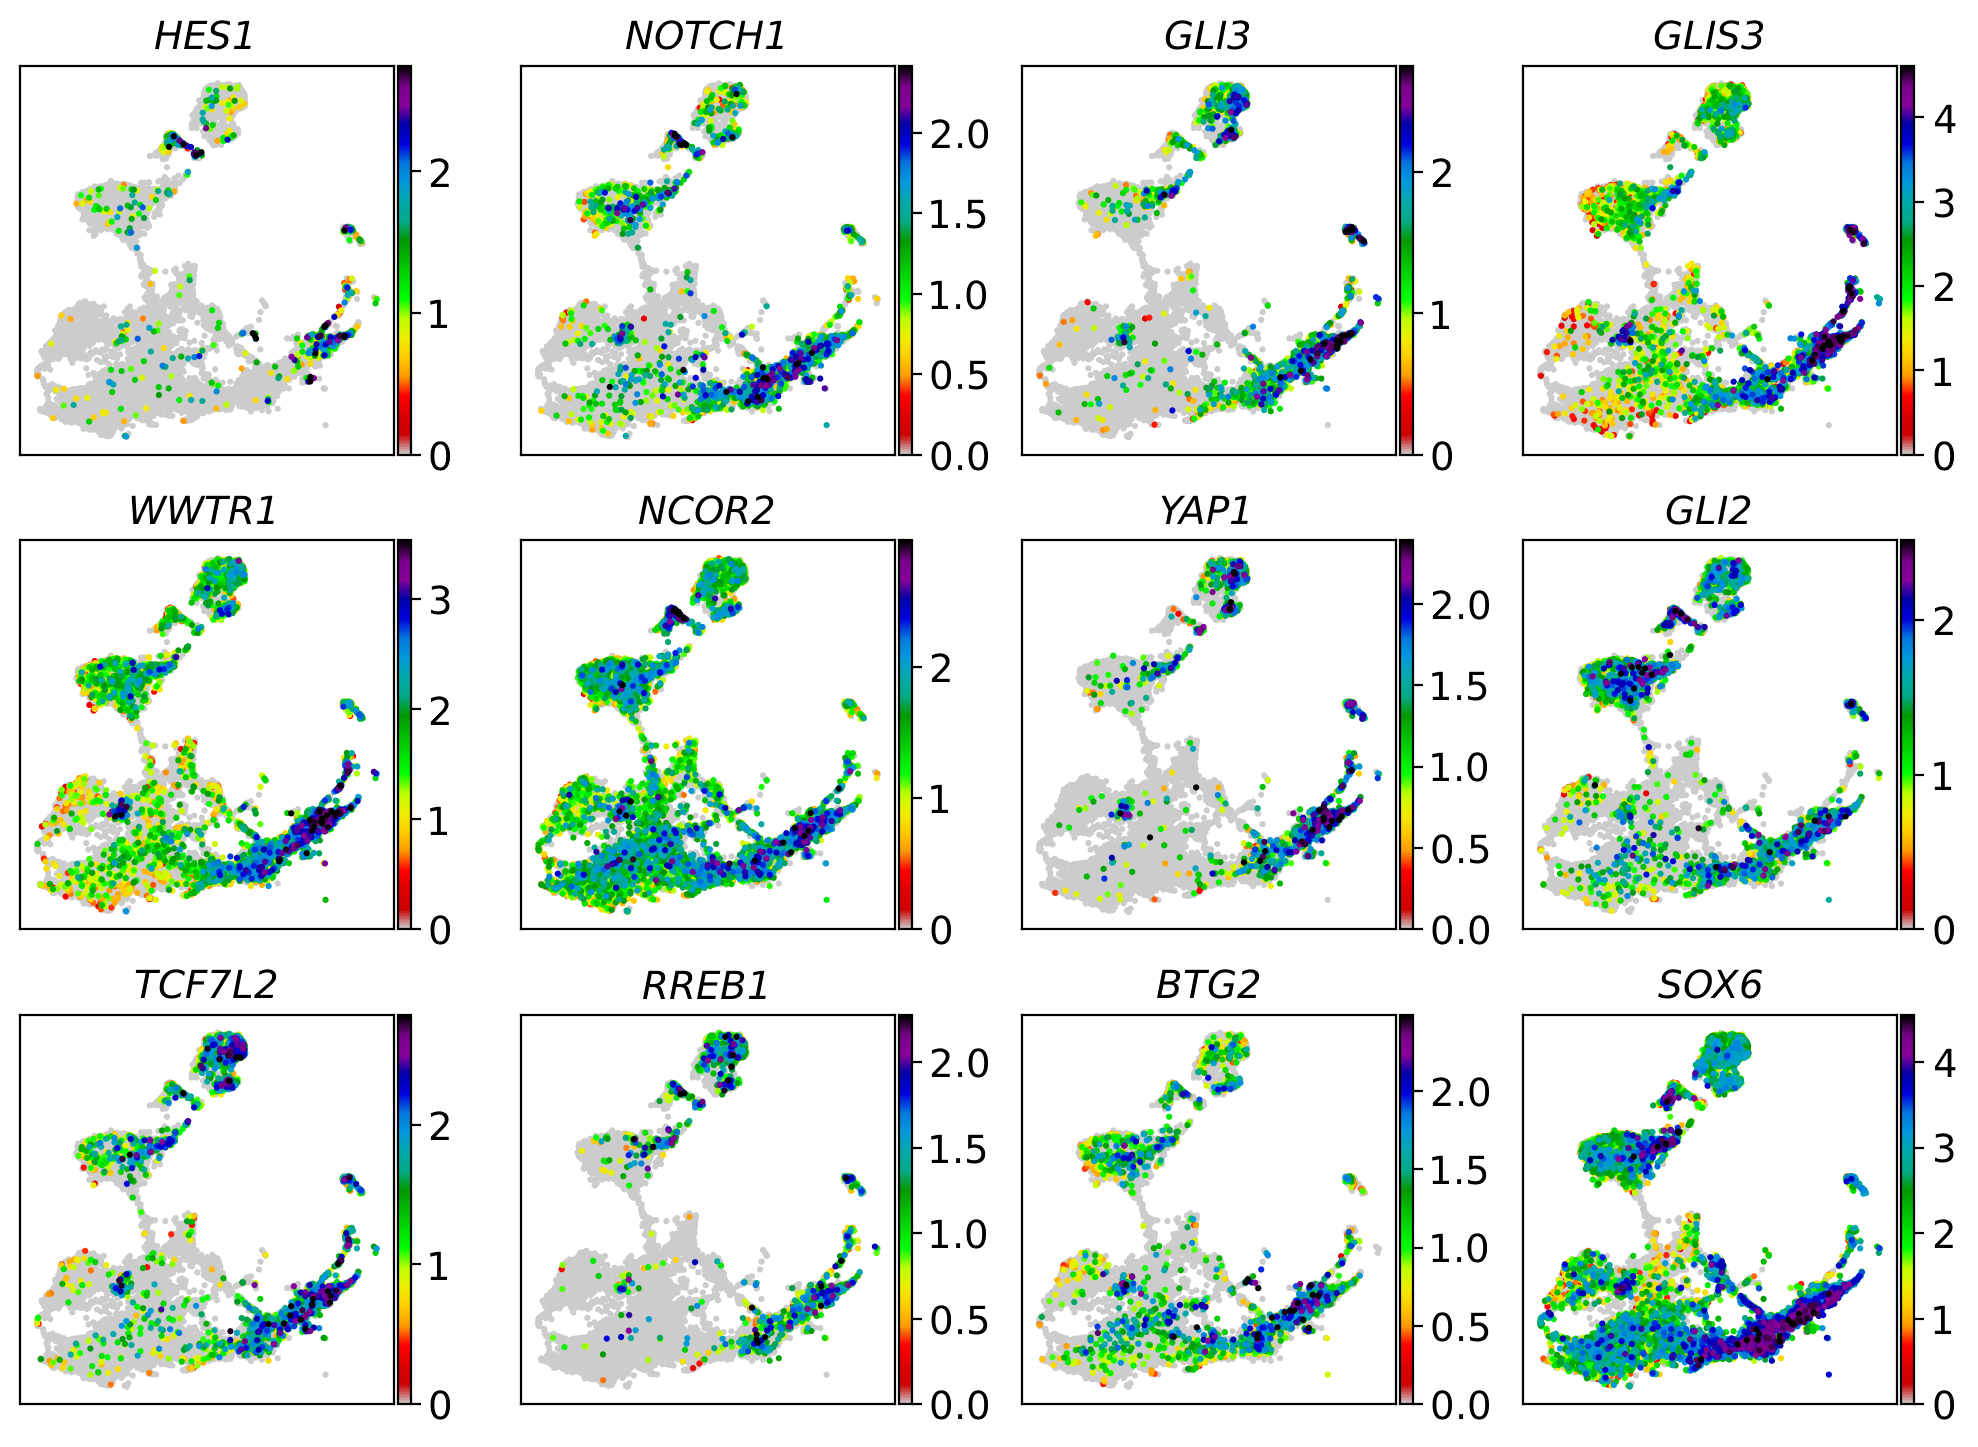

In [22]:
axes = scanpy.pl.embedding(adata, "umap", color=pv_drivers, vmin=0, vmax="p99.9", show=False, cmap="nipy_spectral_r",
                           sort_order=True, wspace=0.22, hspace=0.22, s=20)
figure = axes[0].figure
for gene, axis in zip(pv_drivers, axes):
    axis.set_title("\\textit{"+gene+"}")
    axis.set_xlabel("")
    axis.set_ylabel("")
figure.set_size_inches(12, 8)
pyplot.show()
figure.savefig("Graphs/pv_driver_expression.png", dpi=300, bbox_inches="tight")

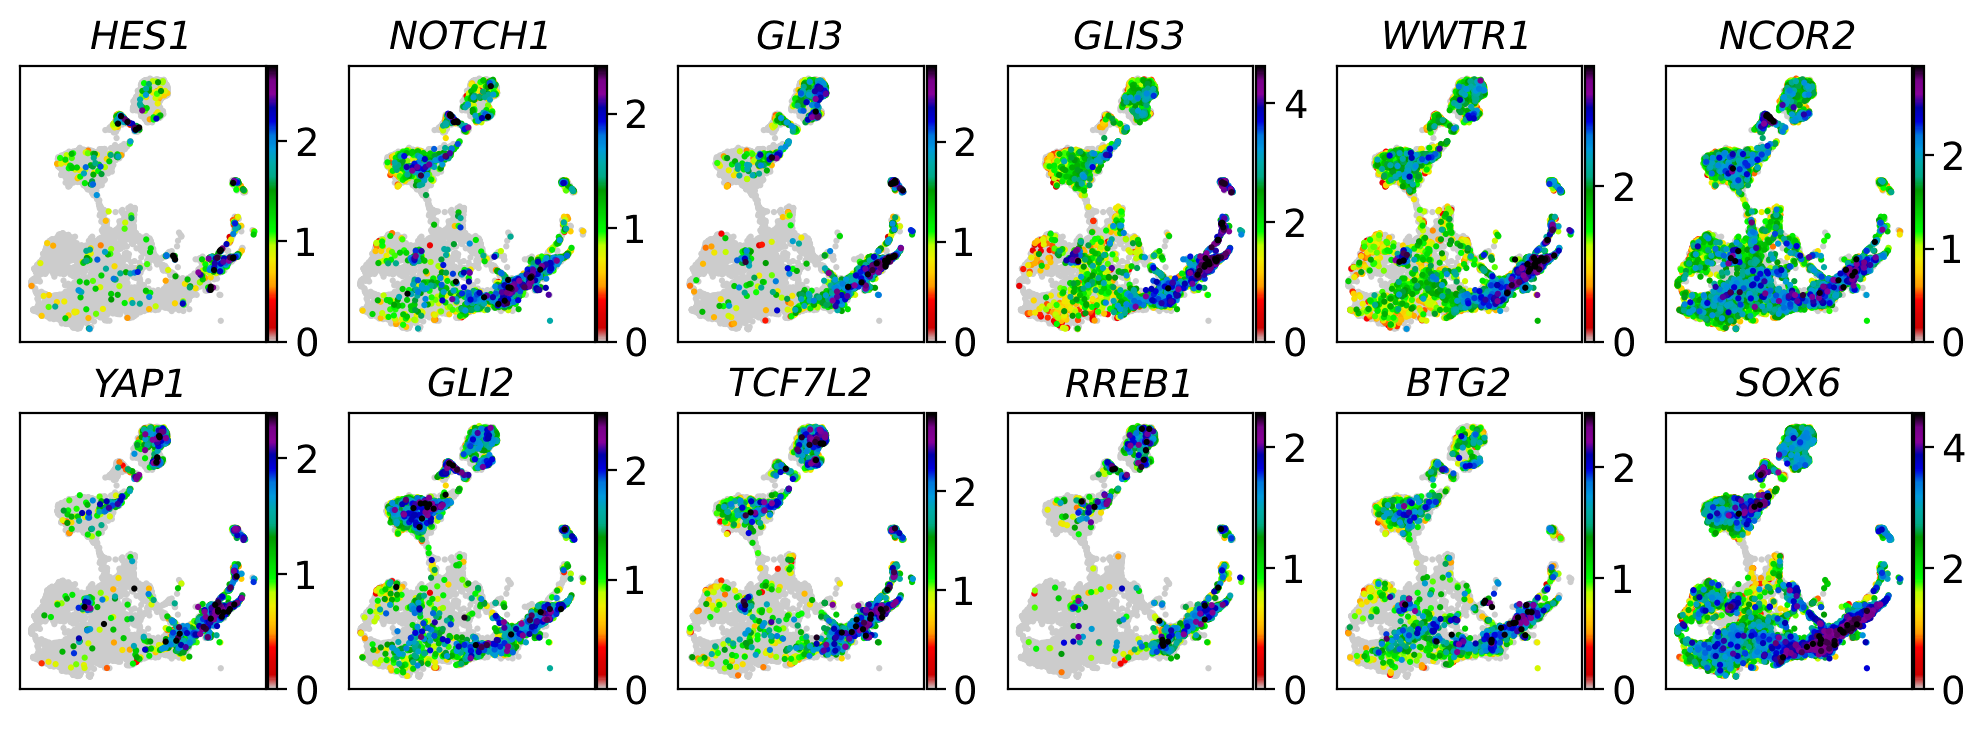

In [21]:
axes = scanpy.pl.embedding(adata, "umap", color=pv_drivers, vmin=0, vmax="p99.9", show=False, cmap="nipy_spectral_r",
                           sort_order=True, wspace=0.22, hspace=0.26, s=20, ncols=6)
figure = axes[0].figure
for gene, axis in zip(pv_drivers, axes):
    axis.set_title("\\textit{"+gene+"}")
    axis.set_xlabel("")
    axis.set_ylabel("")
figure.set_size_inches(12, 3.8)
pyplot.show()
figure.savefig("Graphs/pv_driver_expression_2col.png", dpi=300, bbox_inches="tight")

  0%|          | 0/12 [00:00<?, ?gene/s]

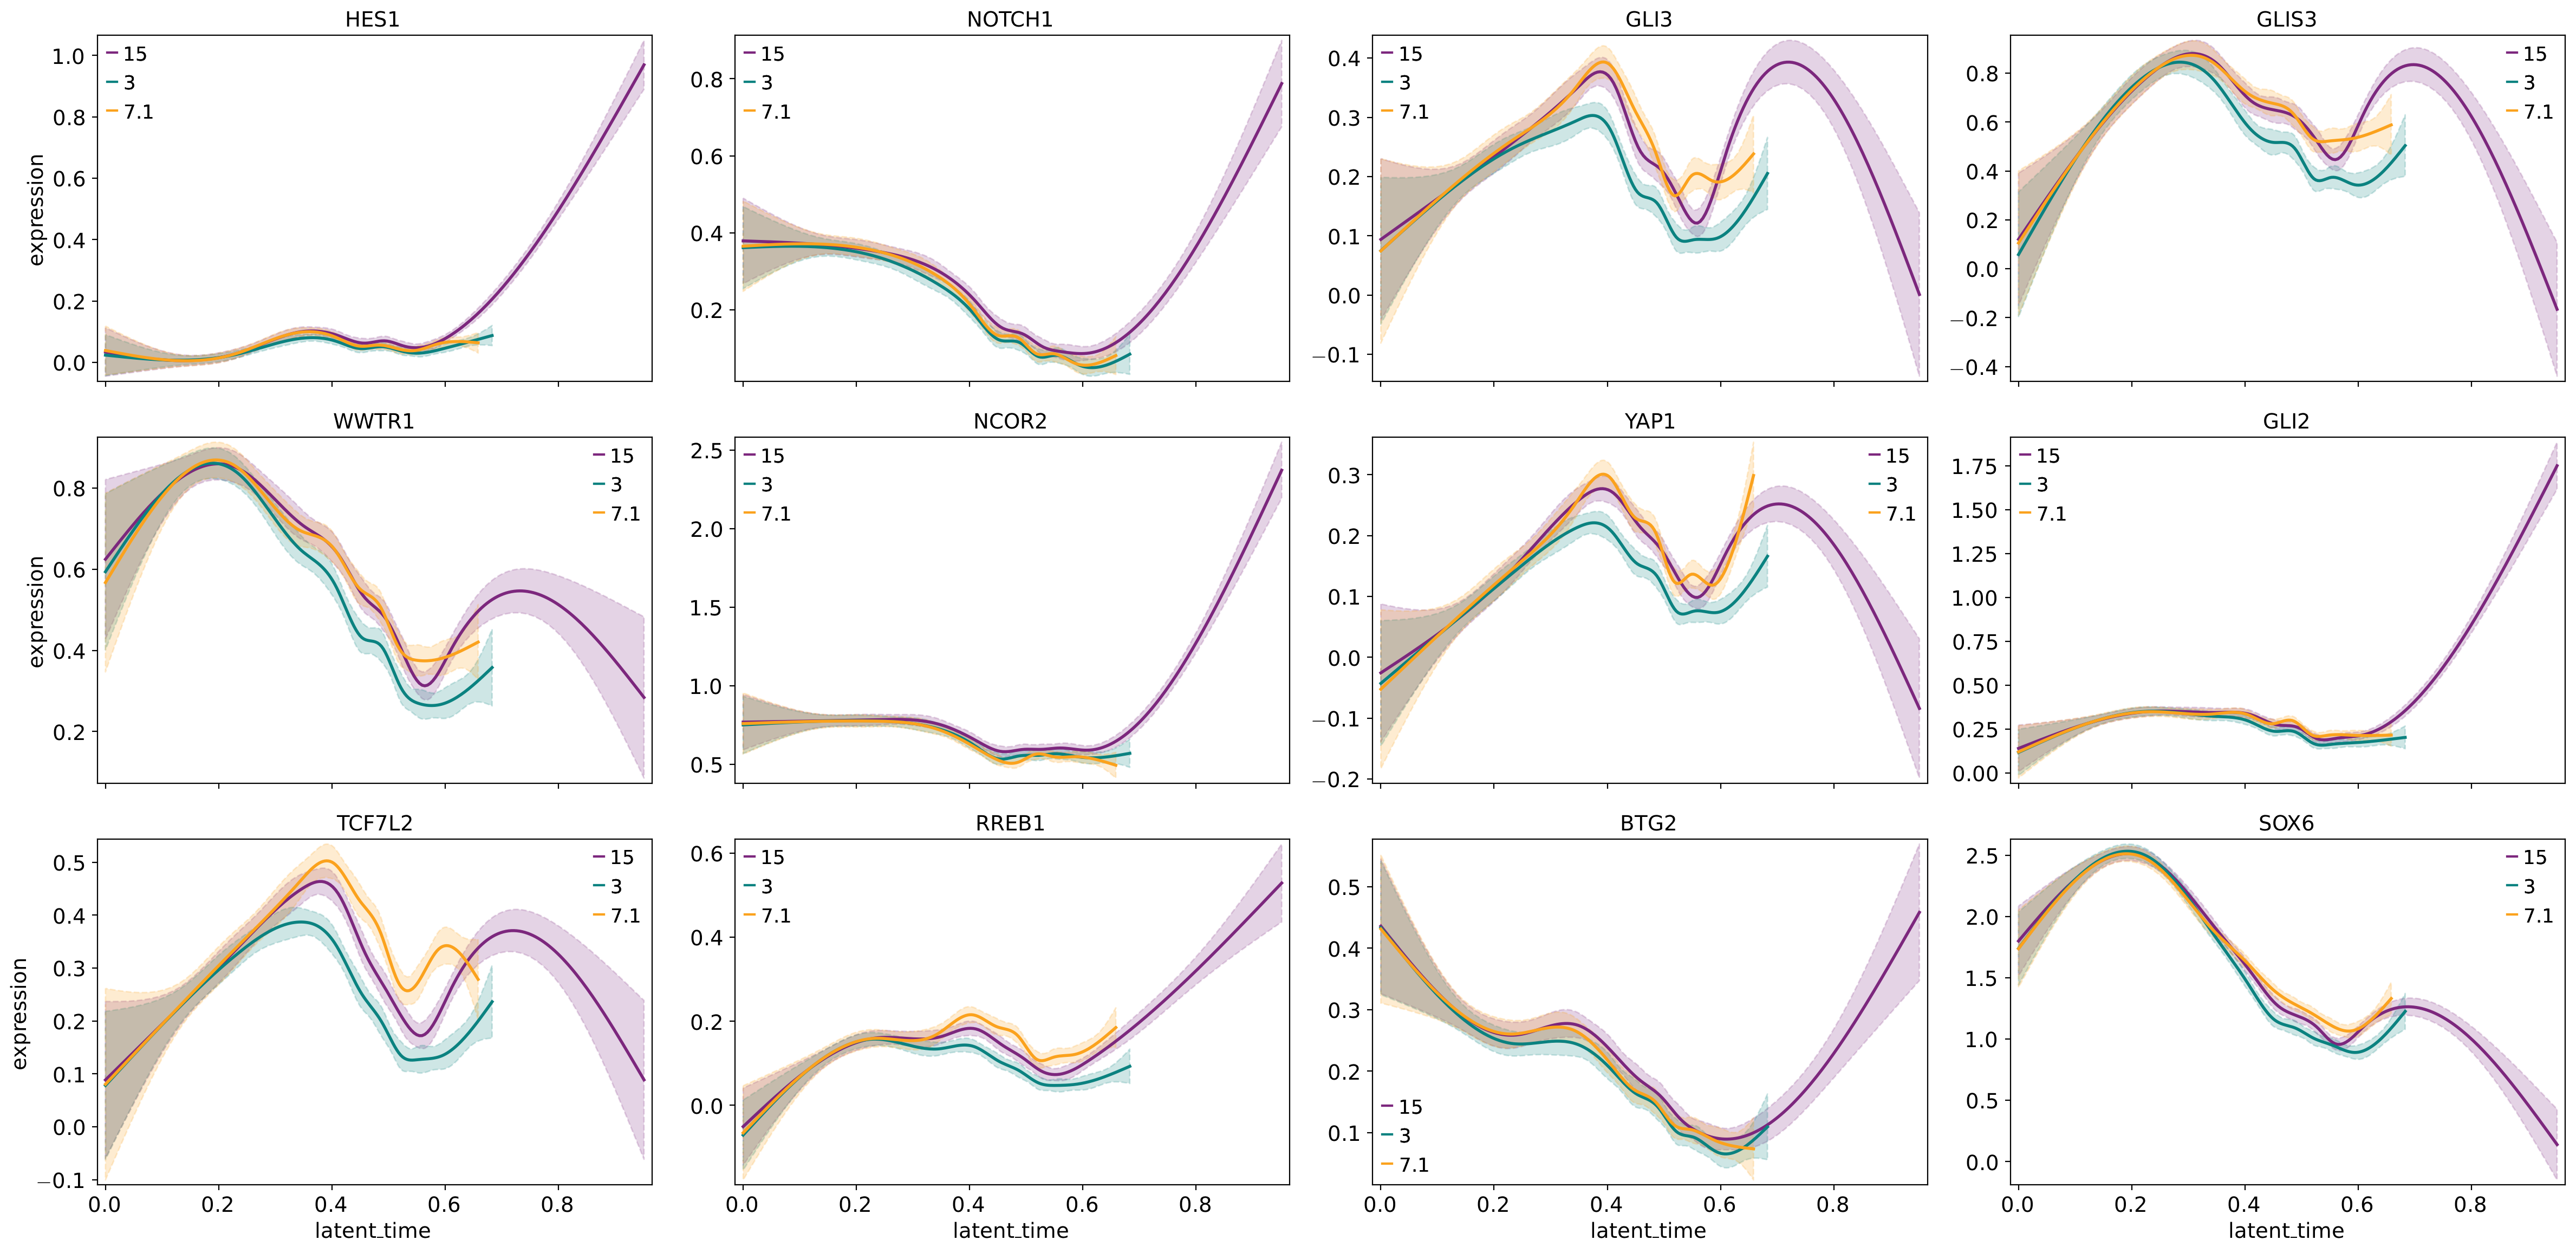

In [52]:
single_cell_analysis.plot_trends_by_trajectory(adata, pv_drivers, layer="raw")

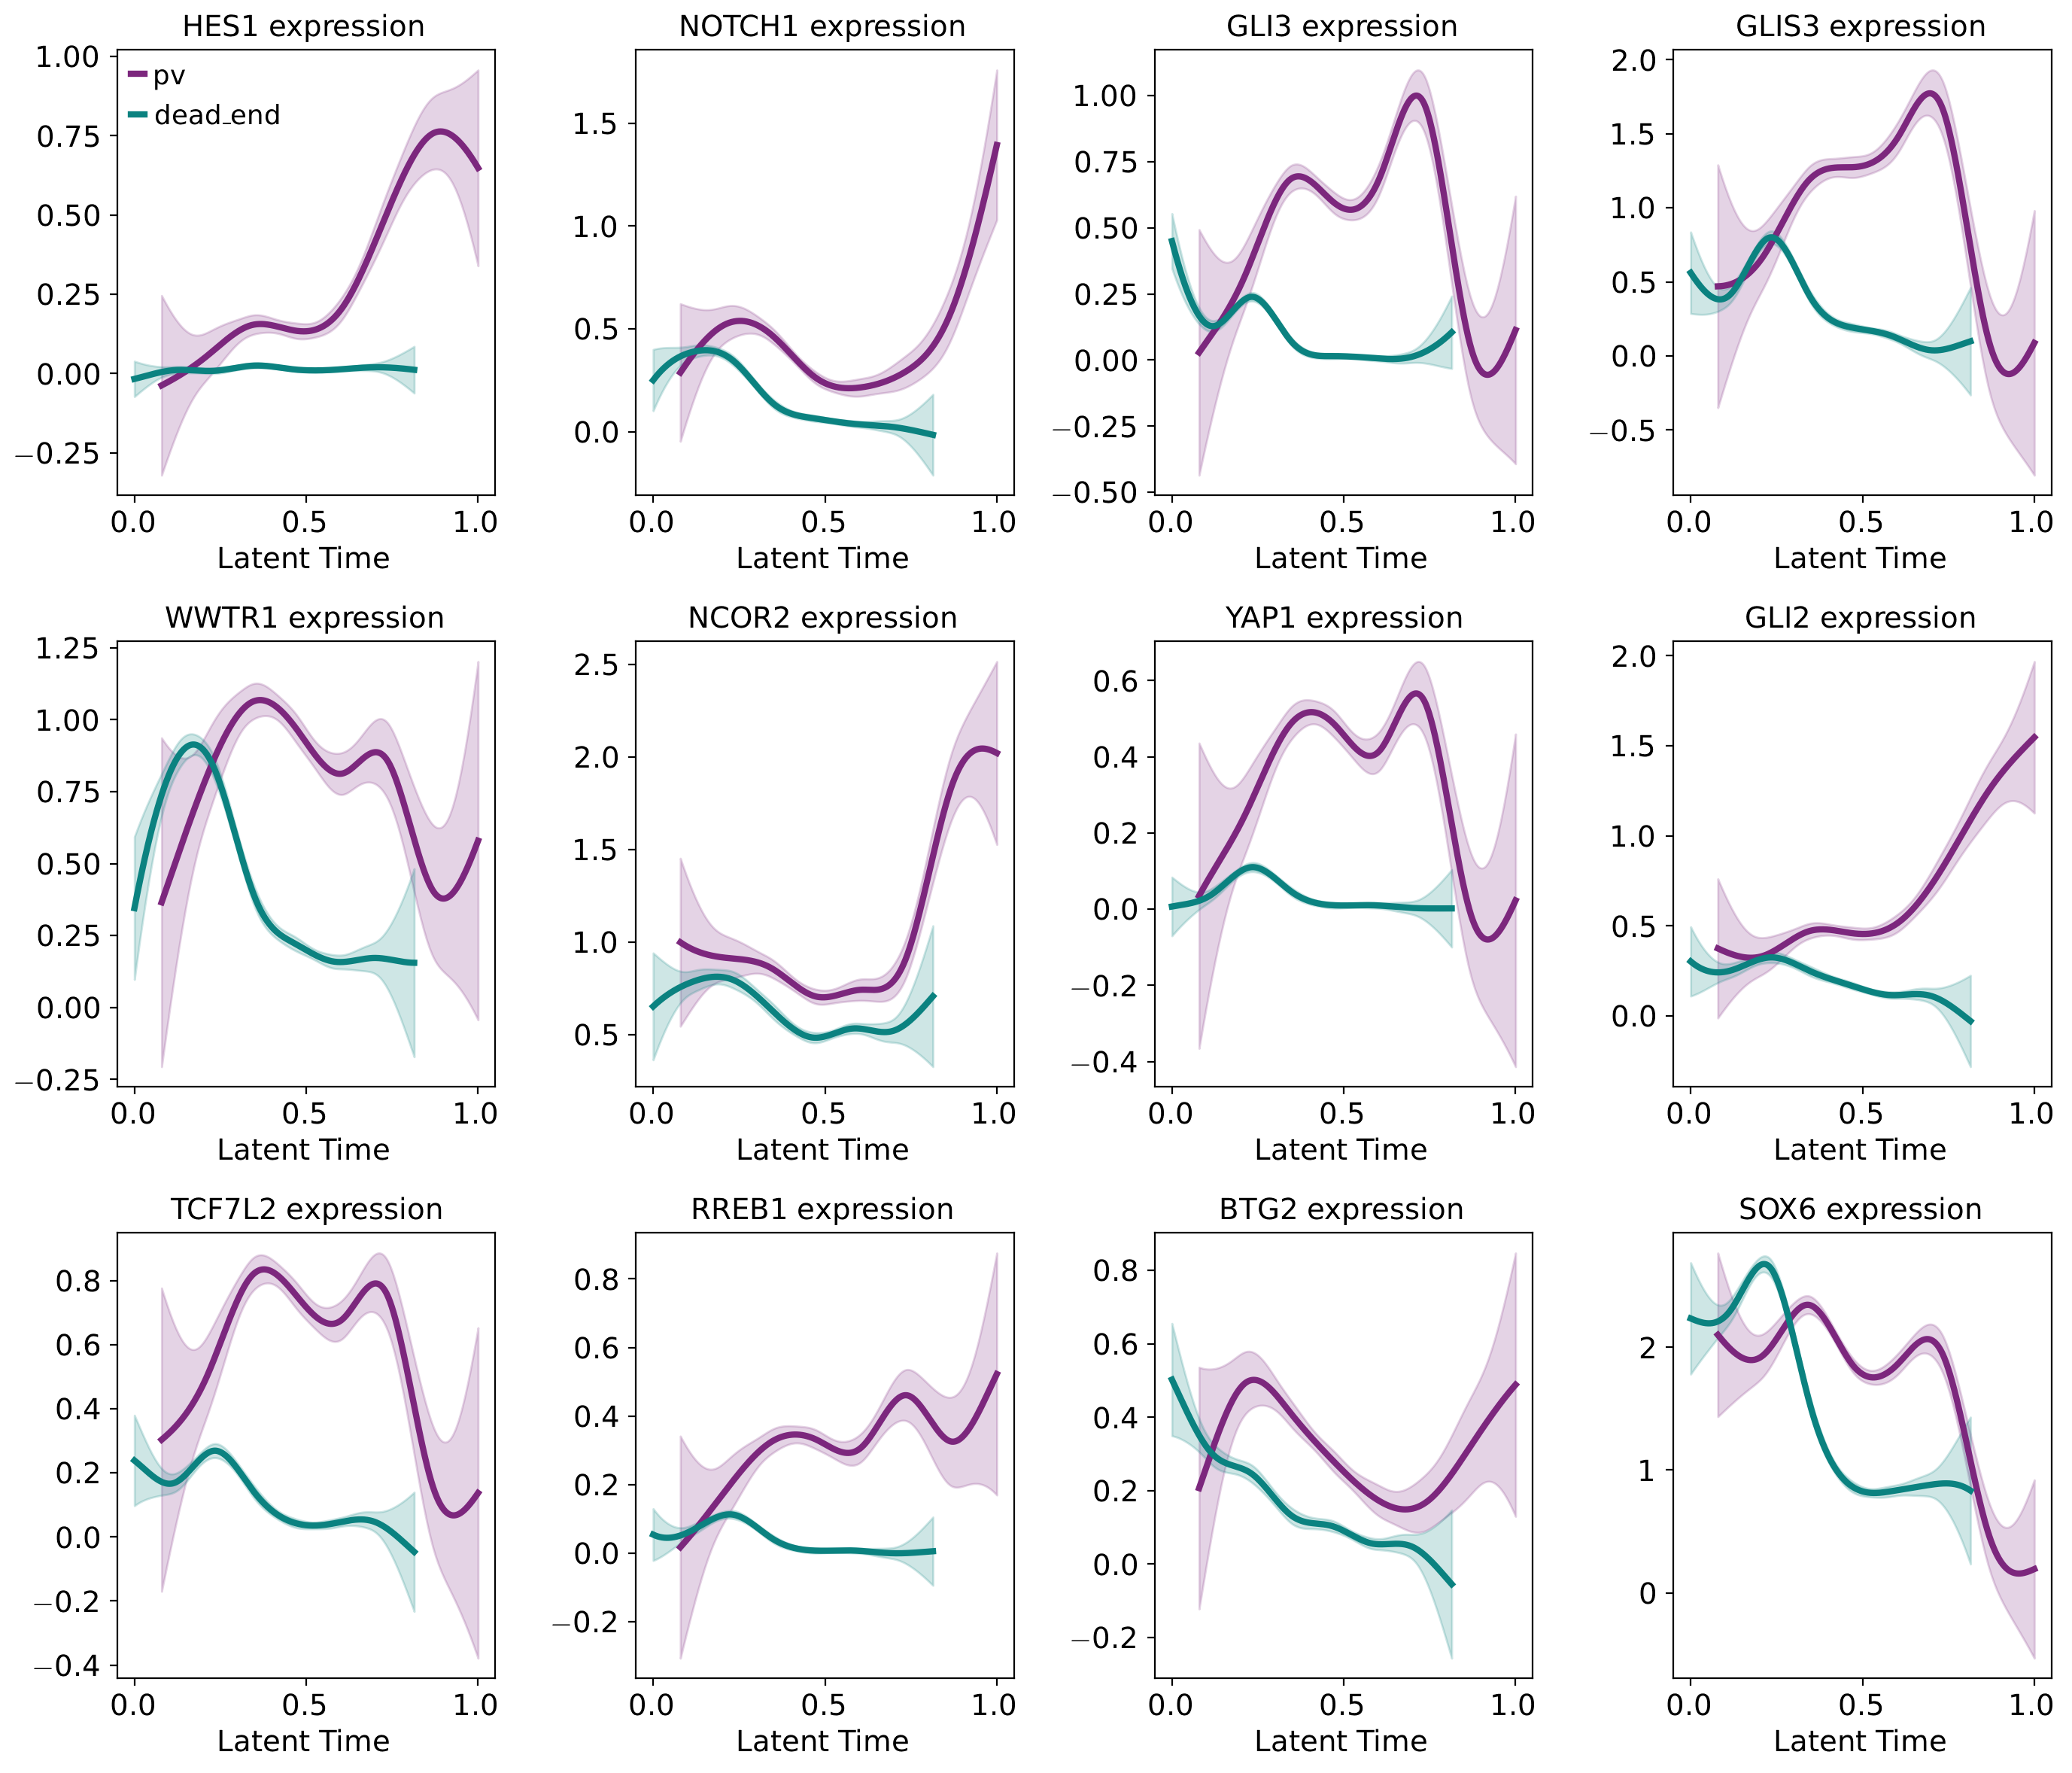

In [53]:
# Expression of drivers for trajecteries defined by clusters

single_cell_analysis.plot_grouped_gene_trend(
    adata, 
    pv_drivers, 
    group_key="trajectory", 
    layer="raw", 
    groups=["pv", "dead_end"],
    n_splines=10
)

# Differential expression analysis in PV cluster

To determine if the drivers or their targets are upregulated in the PV cluster, which is called 15, a differential expression analysis is performed.

In [11]:
# Rank genes

scanpy.tl.rank_genes_groups(
    adata,
    groupby="cluster",
    method="wilcoxon",
    key_added="cluster_rank_genes",
    use_raw=True
)

In [12]:
# Rank genes in PV cluster

rank_df = scanpy.get.rank_genes_groups_df(
        adata,
        key="cluster_rank_genes",
        group="15"
    )
rank_df.index = rank_df["names"]
rank_df = rank_df.drop(columns="names")

In [13]:
# Most upregulated transcription factors

pv_de = rank_df.loc[numpy.intersect1d(tf_array, rank_df.index)].sort_values("scores", ascending=False).head(20).index
rank_df.loc[pv_de].sort_values("scores", ascending=False)

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
NCOR2,17.019306,1.857231,5.906640e-65,3.356573e-62
FOXP4,16.019733,3.592728,9.304969e-58,4.215906e-55
ZBTB7C,14.938216,4.279774,1.858838e-50,6.425064e-48
FOXO1,14.748525,2.361664,3.144649e-49,1.041374e-46
ZFHX2,14.669212,1.793523,1.015164e-48,3.241564e-46
PRDM16,14.196047,2.881602,9.692829e-46,2.685795e-43
ZMIZ1,14.065172,1.384229,6.217125e-45,1.654347e-42
GLI2,13.518288,2.184907,1.219822e-41,2.840152e-39
KMT2C,12.757577,0.834147,2.828625e-37,5.546091e-35


In [14]:
rank_df.loc[pv_drivers]

,scores,logfoldchanges,pvals,pvals_adj
names,,,,
HES1,9.924712,3.320199,3.250392e-23,3.448708e-21
NOTCH1,5.311355,1.463667,1.088134e-07,2.895474e-06
GLI3,-1.190829,-0.752540,2.337208e-01,9.685167e-01
GLIS3,-6.698168,-2.526691,2.110482e-11,8.979727e-10
WWTR1,-1.871953,-0.627482,6.121310e-02,3.649276e-01
NCOR2,17.019306,1.857231,5.906640e-65,3.356573e-62
YAP1,-3.330293,-2.959959,8.675471e-04,1.038084e-02
GLI2,13.518288,2.184907,1.219822e-41,2.840152e-39
TCF7L2,-0.670836,-0.280937,5.023248e-01,1.000000e+00


Many of the PV drivers are upregulated in the PV cluster, including NCOR2, ZBTB7C, PRDM16 and HES1.

# Check target enrichment

The CollecTRI database is used to estimate which TFs have targets upregulated in the PV cluster and in the PV trajectory.

## Upregulation in PV trajectory, ULM

In [15]:
ulm_driver_df.sort_values("Activity", ascending=False).head(20)

,Activity,Adjusted p-value
SP1,8.496870,1.047400e-14
SMAD3,7.083008,3.713518e-10
REST,6.929919,7.378037e-10
MYC,6.619149,4.733117e-09
SOX2,6.485297,9.270652e-09
PRRX1,6.254283,3.477236e-08
ATF4,6.203234,4.126738e-08
STAT3,6.084408,7.625987e-08
HOXA5,5.376405,4.386749e-06
AP1,5.311759,5.639282e-06


In [16]:
# Top PV drivers, ULM

ulm_driver_df.loc[pv_drivers].sort_values("Activity", ascending=False)

,Activity,Adjusted p-value
NCOR2,3.594743,0.004093
YAP1,3.207418,0.012577
NOTCH1,2.567987,0.058028
TCF7L2,2.213969,0.109907
SOX6,1.873150,0.200671
WWTR1,1.699173,0.250774
HES1,1.312536,0.401059
GLI3,0.985431,0.571333
GLIS3,0.649680,0.747770
BTG2,-0.136584,0.955982


## Upregulation in PV cluster, ULM

In [17]:
# TF activities in PV cluster, ULM

data = rank_df[["scores"]].T.dropna(axis=1)
tf_acts, tf_padj = decoupler.mt.ulm(data=data, net=modified_collectri, tmin=5)
ulm_pv_df = pandas.DataFrame(data={"Activity": tf_acts.transpose()["scores"], "Adjusted p-value": tf_padj.transpose()["scores"]}, index=tf_acts.columns)
ulm_pv_df.sort_values("Activity", ascending=False).head(20)

,Activity,Adjusted p-value
HOXB1,6.526776,2.081945e-08
TRPS1,5.546990,3.778379e-06
KLF8,5.166038,1.773005e-05
PAWR,4.908563,5.285665e-05
YAP1,4.395372,4.563177e-04
WWTR1,4.387612,4.563177e-04
TCF3,4.088397,1.604803e-03
NR1H3,3.991263,2.124212e-03
IRF2,3.923768,2.567526e-03
ZMYND8,3.837673,3.379568e-03


In [18]:
# Whether the targets of the drivers are upregulated in cluster 15, ULM

ulm_pv_df.loc[pv_drivers].sort_values("Activity", ascending=False)

,Activity,Adjusted p-value
YAP1,4.395372,0.000456
WWTR1,4.387612,0.000456
NCOR2,2.797073,0.071959
HES1,2.743207,0.079727
SOX6,1.246227,0.694609
GLI3,0.755311,0.911261
GLI2,-0.002536,0.997977
RREB1,-0.213623,0.969668
GLIS3,-0.477714,0.921357
BTG2,-0.676745,0.911261


## Score single cells

Activities in single cells were scored with ULM, MLM and Z-scores and their results were compared.

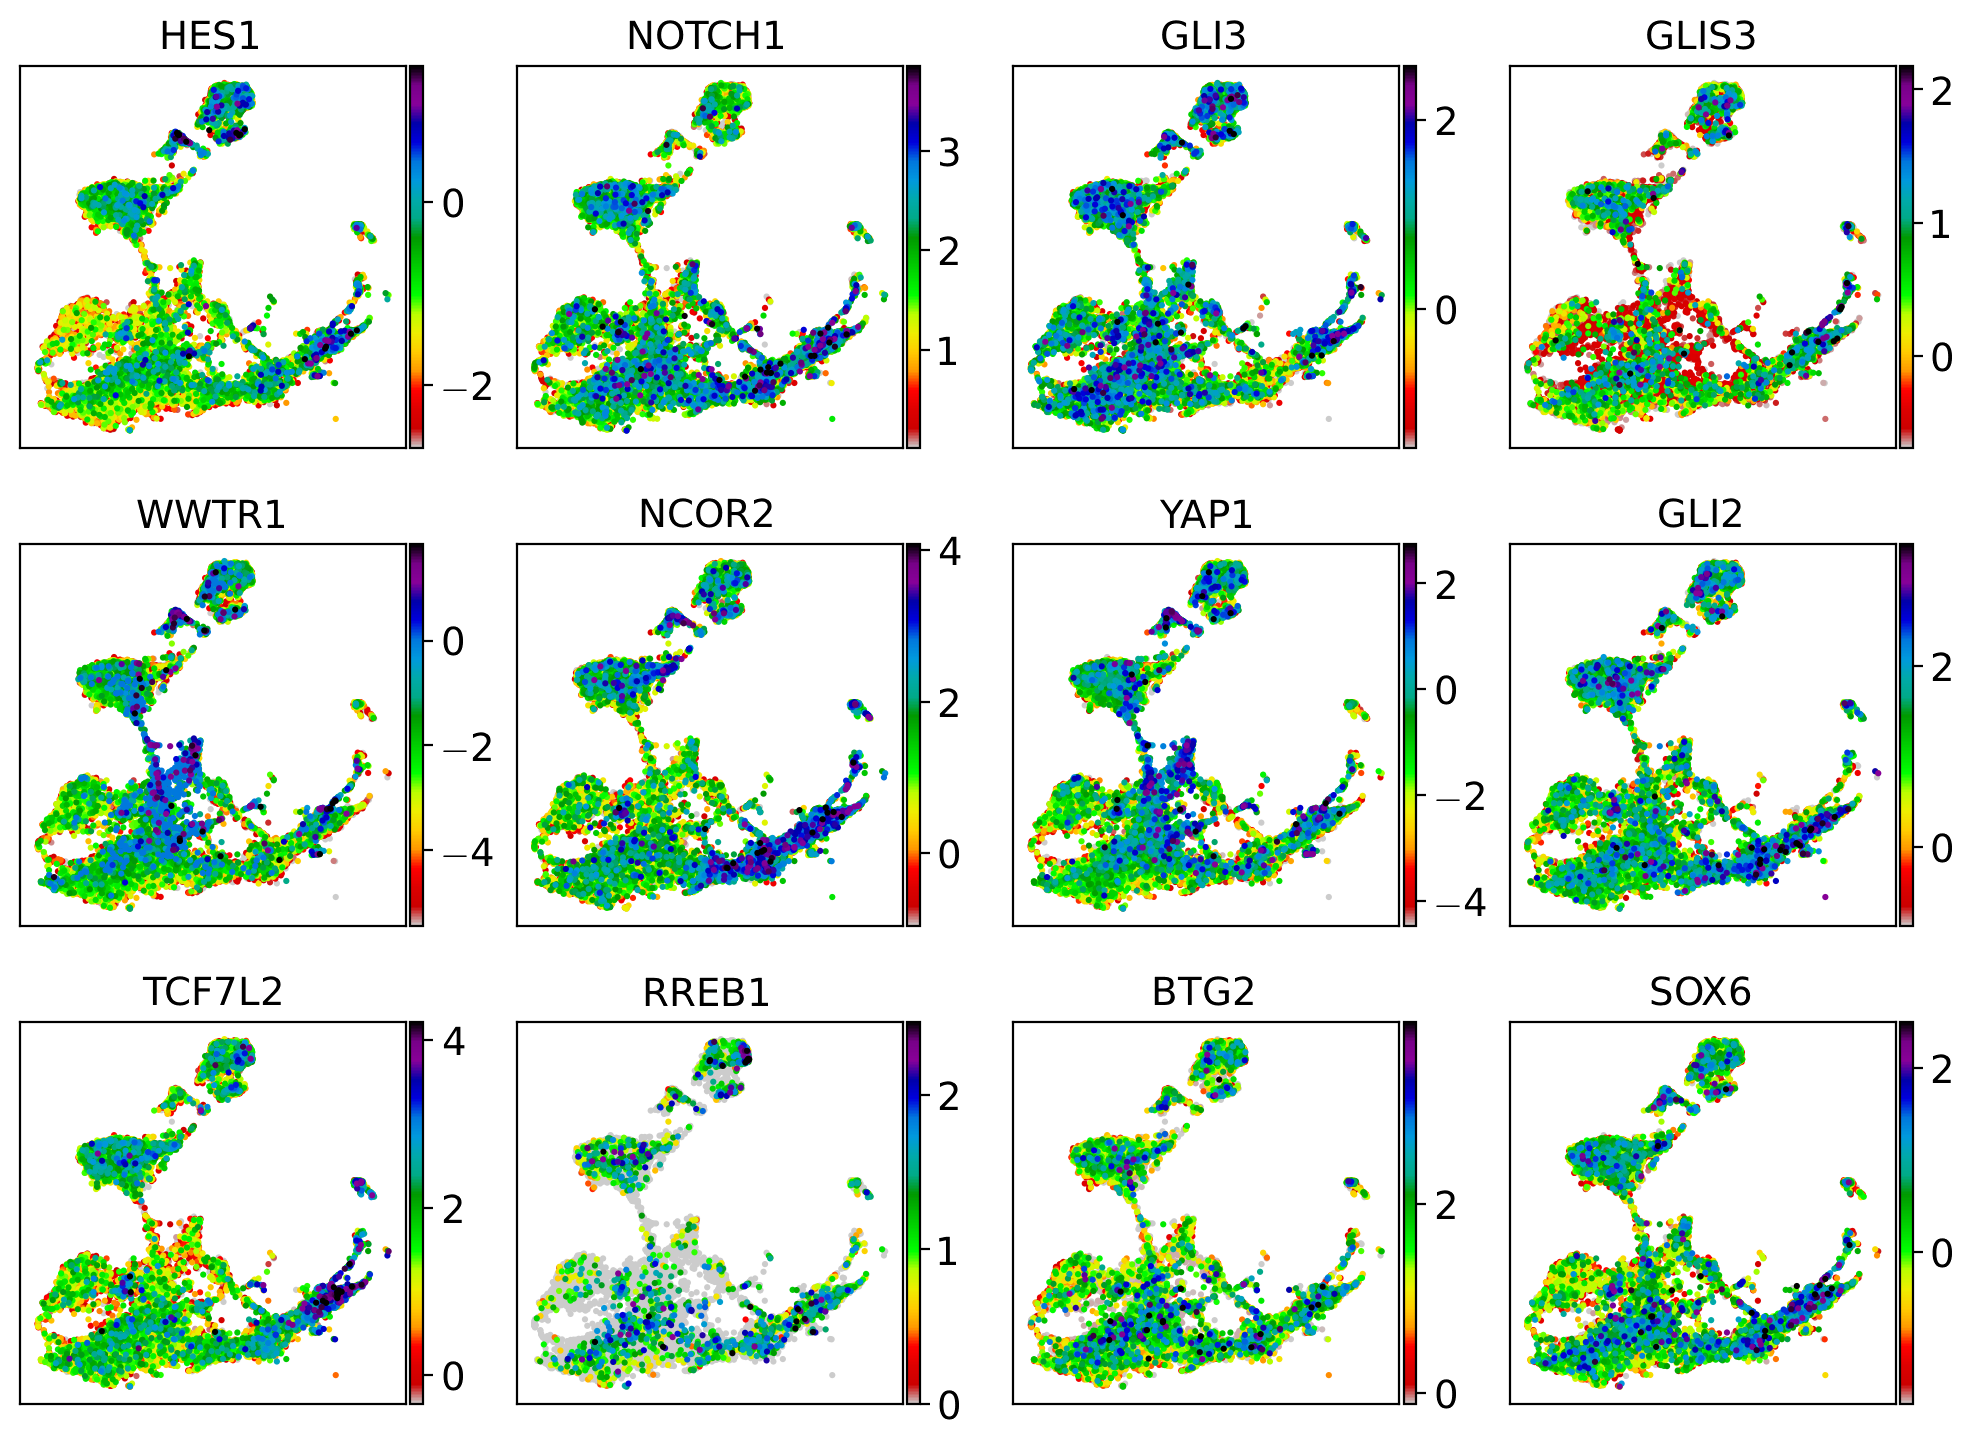

In [19]:
# Activities of all PV drivers

ulm_keys = []
for tf in pv_drivers:
    ulm_scores = adata.obsm["score_ulm"][tf]
    adata.obs[f"{tf}_ulm"] = ulm_scores
    ulm_keys.append(f"{tf}_ulm")

axes = scanpy.pl.embedding(adata, "umap", color=ulm_keys, cmap="nipy_spectral_r", vmin="p10", vmax="p99.9", ncols=4, s=20, show=False)
figure = axes[0].figure
for gene, axis in zip(pv_drivers, axes):
    axis.set_title(f"{gene}")
    axis.set_xlabel("")
    axis.set_ylabel("")
figure.set_size_inches(12, 8)
pyplot.show()
figure.savefig("Graphs/pv_driver_activity.png", dpi=300, bbox_inches="tight")

# Roadblock TFs

So identify potential roadblocks to PV reprogramming, transcription factors whose expression are anticorrelated with PV fate probability are investigated.

In [72]:
pv_roadblocks = driver_df.loc[numpy.intersect1d(ulm_driver_df.index, driver_df.index)].sort_values("15_corr", ascending=True).head(12).index.to_list()
print(f"PV roadblocks:\n{pv_roadblocks}")

PV roadblocks:
['SOX5', 'THRB', 'TCF4', 'NFIB', 'ZEB2', 'PBX1', 'ZBTB16', 'MEF2C', 'HDAC9', 'SOX4', 'NR3C2', 'JARID2']


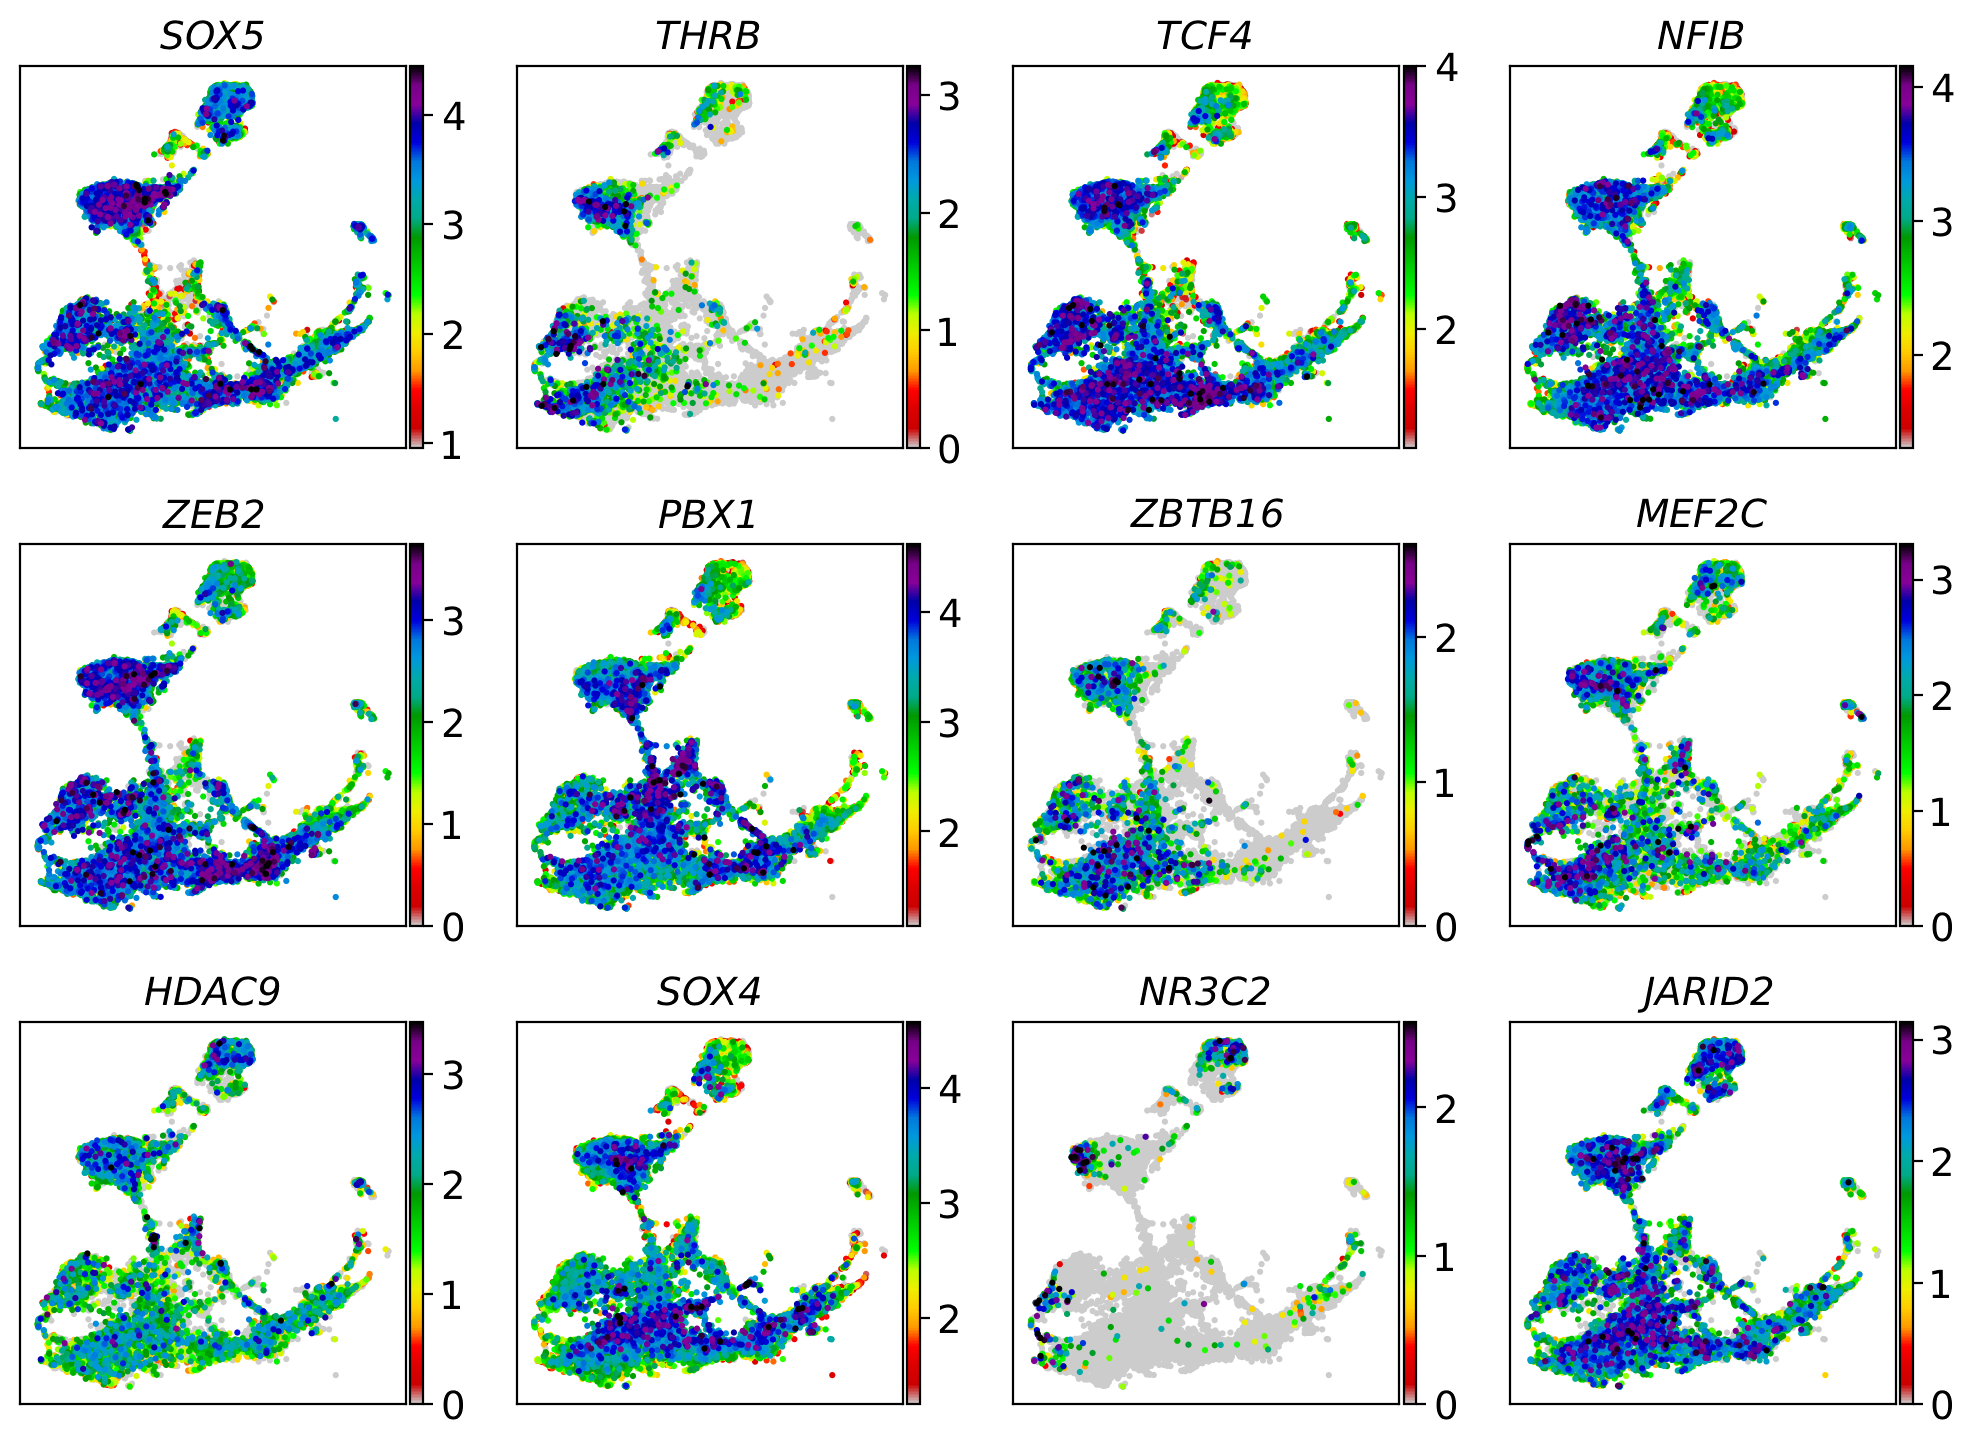

In [79]:
# Plot PV roadblocks on UMAP
axes = scanpy.pl.embedding(
    adata,
    basis="umap",
    color=pv_roadblocks,
    color_map="nipy_spectral_r",
    s=20,
    ncols=4,
    vmax="p99.9",
    vmin="p10",
    show=False
)
figure = axes[0].figure
for gene, axis in zip(pv_roadblocks, axes):
    axis.set_title("\\textit{"+gene+"}")
    axis.set_xlabel("")
    axis.set_ylabel("")
figure.set_size_inches(12, 8)
pyplot.show()
figure.savefig("Graphs/pv_roadblock_expression.png", dpi=300, bbox_inches="tight")

In [80]:
# Estimated activity, ULM for Cellrank drivers

ulm_driver_df.loc[pv_roadblocks].sort_values("Activity", ascending=True)

,Activity,Adjusted p-value
SOX4,-2.789319,0.035020
MEF2C,-1.971096,0.168726
NFIB,-1.500117,0.322123
HDAC9,-1.455141,0.331517
JARID2,-1.150221,0.484843
SOX5,-1.090183,0.515328
TCF4,-1.041021,0.538323
PBX1,0.001528,0.998781
THRB,0.209605,0.927440
ZEB2,0.338219,0.886363


In [81]:
# Estimated activity, ULM for PV macrostate

ulm_pv_df.loc[pv_roadblocks].sort_values("Activity", ascending=True)

,Activity,Adjusted p-value
SOX4,-3.300488,0.018465
SOX5,-2.620647,0.107873
MEF2C,-2.135940,0.244478
PBX1,-1.880903,0.391860
ZEB2,-0.872914,0.861780
JARID2,-0.731943,0.911261
TCF4,-0.119736,0.982330
NR3C2,0.024248,0.995502
HDAC9,0.485097,0.921357
ZBTB16,0.561041,0.921357


Most likely to be downregulated in PV trajectory: TCF4, MEF2C, SOX5, PBX1 (not in adata)

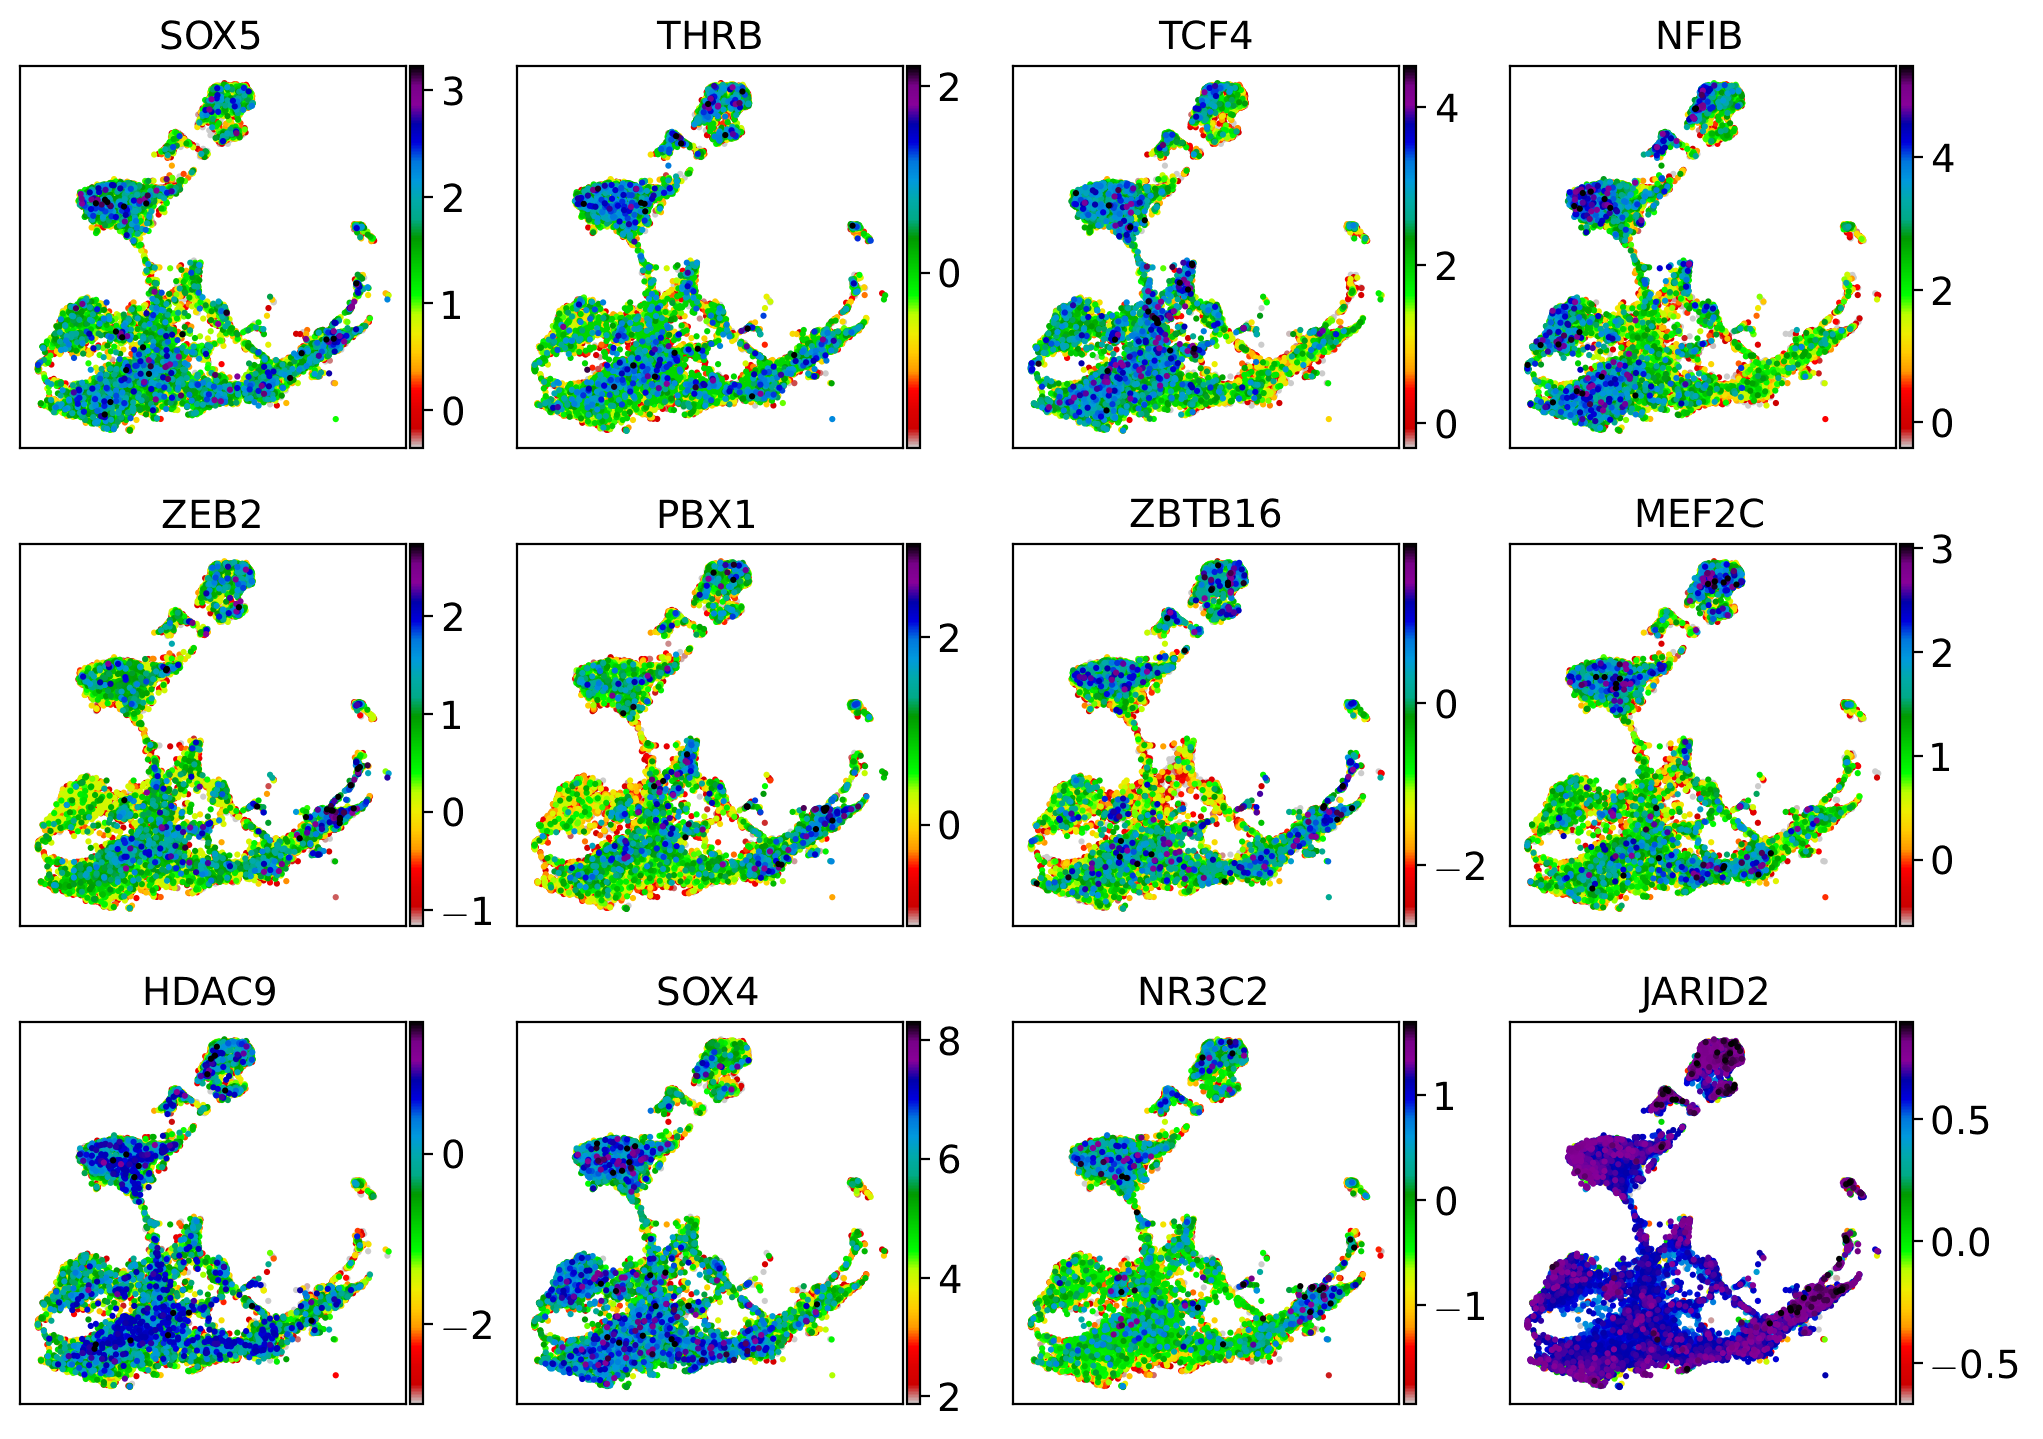

In [124]:
# Compare expression and activity trends

roadblock_keys = []
for tf in pv_roadblocks:
    if not tf in adata.obsm["score_ulm"].columns:
        continue
    scores = adata.obsm["score_ulm"][tf]
    activity_key = f"{tf}_ulm"
    adata.obs[activity_key] = scores
    roadblock_keys.append(activity_key)

axes = scanpy.pl.embedding(
    adata,
    basis="umap",
    color=roadblock_keys,
    color_map="nipy_spectral_r",
    s=20,
    ncols=4,
    vmax="p99.9",
    vmin="p10",
    show=False
)
figure = axes[0].figure
for gene, axis in zip(pv_roadblocks, axes):
    axis.set_title(f"{gene}")
    axis.set_xlabel("")
    axis.set_ylabel("")
figure.set_size_inches(12, 8)
pyplot.show()
figure.savefig("Graphs/pv_roadblock_activity.png", dpi=300, bbox_inches="tight")

# Table for driver genes

In [ ]:
driver_table = pandas.DataFrame(index = driver_df.loc[pv_drivers].index)
driver_table["Gene"] = driver_table.index
driver_table["Gene"] = driver_table["Gene"].apply(lambda x: f"\\textit{{{x}}}")
driver_table["PV trajectory expression"] = driver_df.loc[pv_drivers, ["15_corr"]]

activity_list = []
for tf in driver_table.index:
    if tf in ulm_driver_df.index:
        activity_list.append(ulm_driver_df.loc[tf, "Activity"])
    else:
        activity_list.append(pandas.NA)
driver_table["PV trajectory activity"] = activity_list

driver_table["PV differential expression"] = rank_df.loc[driver_table.index, ["scores"]]
dead_end_activity_list = []
for tf in driver_table.index:
    dead_end_activity_list.append(ulm_pv_df.loc[tf, "Activity"])
driver_table["PV differential activity"] = dead_end_activity_list

IPython.display.display(driver_table.drop(columns=["Gene"]))

print(driver_table.to_latex(float_format="%.2f", na_rep="NA", index=False, column_format="l"+"C"*(len(driver_table.columns)-1), escape=False))

,PV trajectory expression,PV trajectory activity,PV differential expression,PV differential activity
HES1,0.285770,1.312536,9.924712,2.743207
NOTCH1,0.277832,2.567987,5.311355,-1.268287
GLI3,0.276936,0.985431,-1.190829,0.755311
GLIS3,0.267810,0.649680,-6.698168,-0.477714
WWTR1,0.263426,1.699173,-1.871953,4.387612
NCOR2,0.250748,3.594743,17.019306,2.797073
YAP1,0.248663,3.207418,-3.330293,4.395372
GLI2,0.243749,-0.606854,13.518288,-0.002536
TCF7L2,0.231178,2.213969,-0.670836,-1.577253
RREB1,0.210274,-0.498859,3.491530,-0.213623


\begin{tabular}{lCCCC}
\toprule
Gene & PV trajectory expression & PV trajectory activity & PV differential expression & PV differential activity \\
\midrule
\textit{HES1} & 0.29 & 1.31 & 9.92 & 2.74 \\
\textit{NOTCH1} & 0.28 & 2.57 & 5.31 & -1.27 \\
\textit{GLI3} & 0.28 & 0.99 & -1.19 & 0.76 \\
\textit{GLIS3} & 0.27 & 0.65 & -6.70 & -0.48 \\
\textit{WWTR1} & 0.26 & 1.70 & -1.87 & 4.39 \\
\textit{NCOR2} & 0.25 & 3.59 & 17.02 & 2.80 \\
\textit{YAP1} & 0.25 & 3.21 & -3.33 & 4.40 \\
\textit{GLI2} & 0.24 & -0.61 & 13.52 & -0.00 \\
\textit{TCF7L2} & 0.23 & 2.21 & -0.67 & -1.58 \\
\textit{RREB1} & 0.21 & -0.50 & 3.49 & -0.21 \\
\textit{BTG2} & 0.20 & -0.14 & 2.92 & -0.68 \\
\textit{SOX6} & 0.20 & 1.87 & 1.03 & 1.25 \\
\bottomrule
\end{tabular}



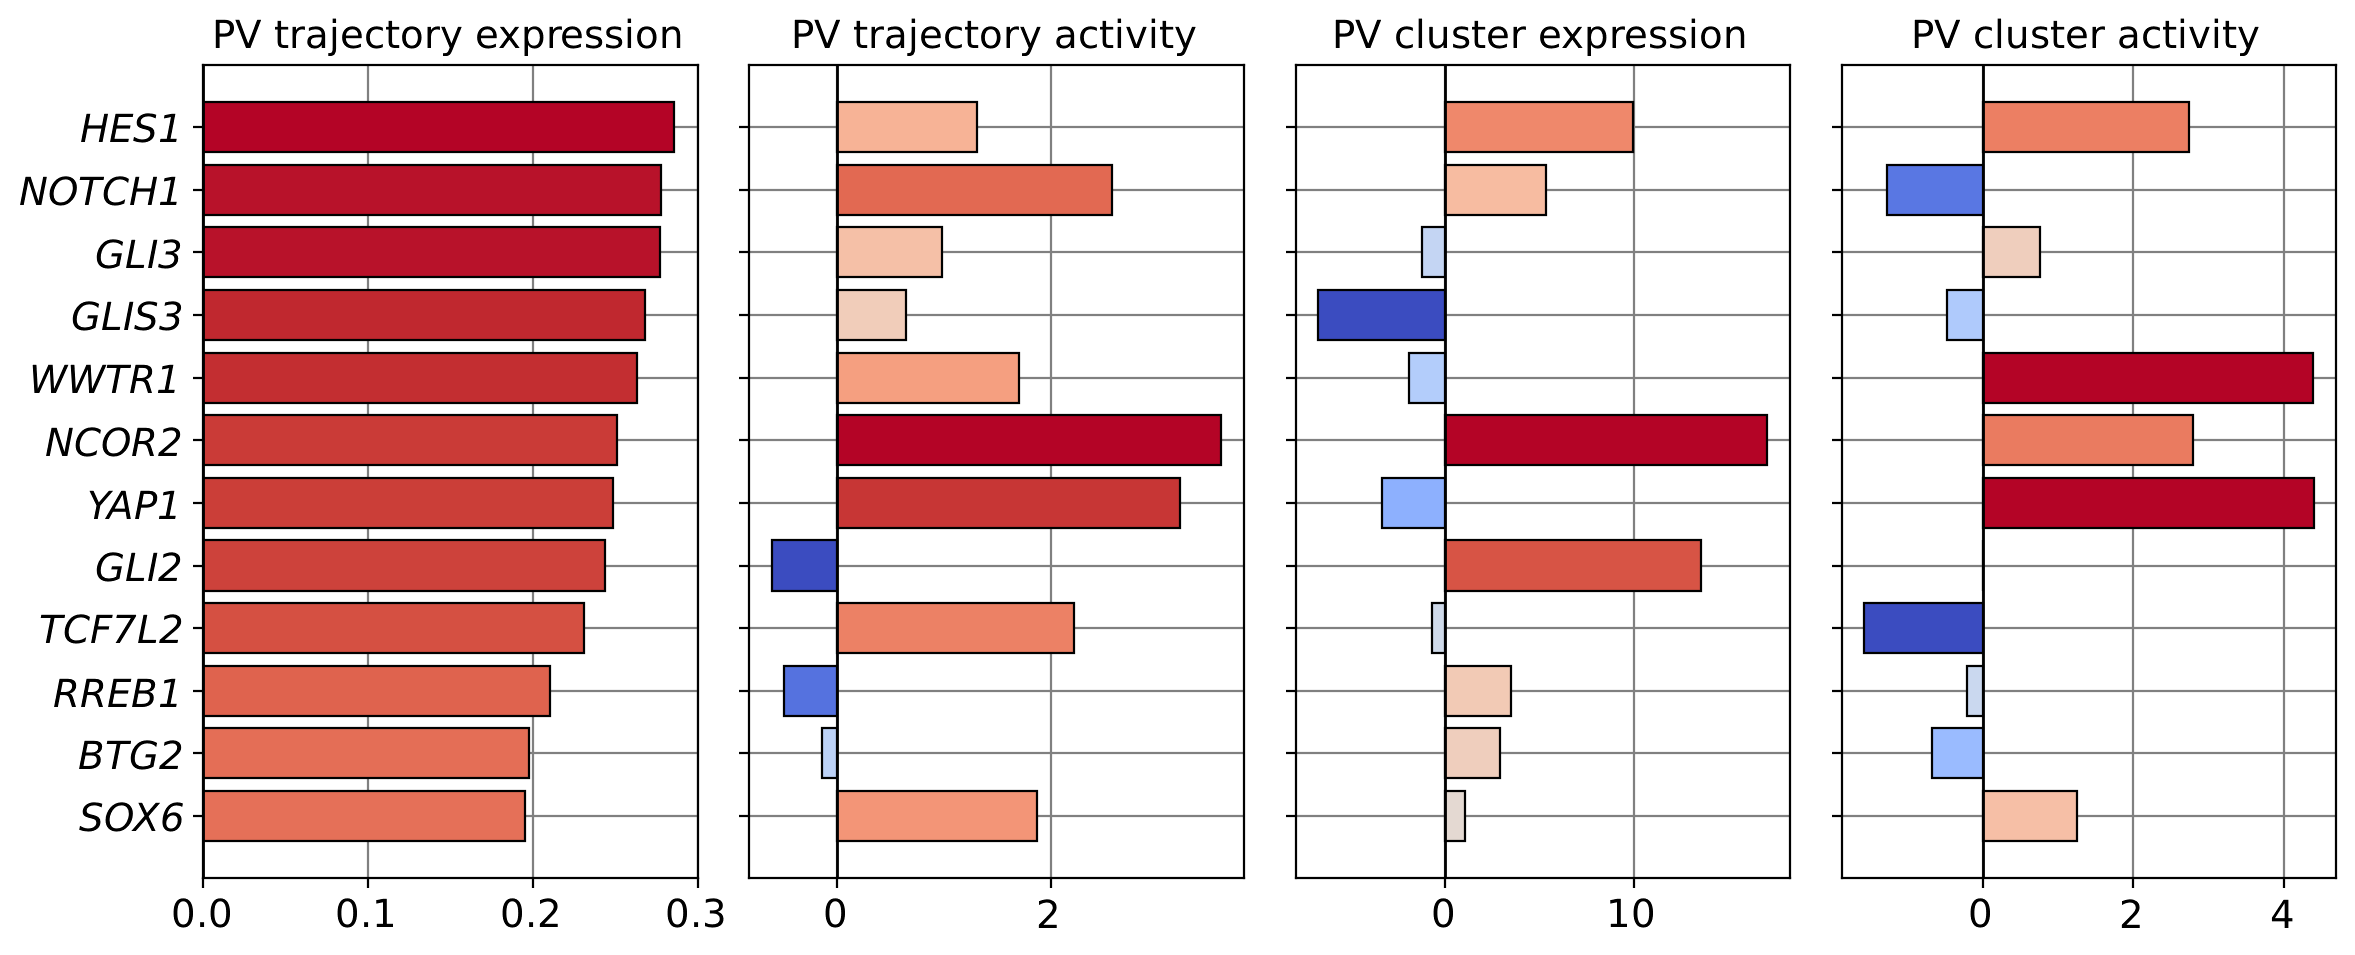

In [122]:
driver_table = pandas.DataFrame(index = driver_df.loc[pv_drivers].index)
driver_table["Gene"] = driver_table.index
driver_table["Gene"] = driver_table["Gene"].apply(lambda x: f"\\textit{{{x}}}")
driver_table["PV trajectory expression"] = driver_df.loc[pv_drivers, ["15_corr"]]

activity_list = []
for tf in driver_table.index:
    if tf in ulm_driver_df.index:
        activity_list.append(ulm_driver_df.loc[tf, "Activity"])
    else:
        activity_list.append(pandas.NA)
driver_table["PV trajectory activity"] = activity_list

driver_table["PV cluster expression"] = rank_df.loc[driver_table.index, ["scores"]]
dead_end_activity_list = []
for tf in driver_table.index:
    dead_end_activity_list.append(ulm_pv_df.loc[tf, "Activity"])
driver_table["PV cluster activity"] = dead_end_activity_list

# define the columns to be plotted
data_columns = driver_table.columns[1:]

# create a figure with four subplots sharing the y-axis
figure, axes = pyplot.subplots(nrows=1, ncols=len(data_columns), figsize=(12, 5), sharey=True)

# plot each metric in a separate panel
for index in range(len(data_columns)):
    column_name = data_columns[index]
    
    # ensure data is numeric for color mapping
    data_values = driver_table[column_name].astype(float)
    minimum_value = data_values.min()
    maximum_value = data_values.max()
    
    # assign colormap and normalization
    colormap = matplotlib.colormaps["coolwarm"]
    # center the diverging colormap at zero
    if minimum_value < 0 and maximum_value > 0:
        norm = matplotlib.colors.TwoSlopeNorm(vmin=minimum_value, vcenter=0, vmax=maximum_value)
    else:
        norm = matplotlib.colors.TwoSlopeNorm(vmin=min(-1e-10, minimum_value), vcenter=0, vmax=max(1e-10, maximum_value))
            
    # map the normalized values to colors
    bar_colors = colormap(norm(data_values))
    
    # extract data and plot horizontal bars with the calculated colors
    axis = axes[index]
    axis.barh(driver_table["Gene"], data_values, color=bar_colors, edgecolor="black", linewidth=0.8)
    axis.set_title(column_name)
    
    # add a vertical line at zero to highlight positive versus negative values
    axis.axvline(0, color="black", linewidth=1.0)

    axis.grid(True, color="grey")
    axis.set_axisbelow(True)

# invert y-axis so the first gene in the dataframe appears at the top
axes[0].invert_yaxis()

pyplot.tight_layout()

pyplot.savefig("Graphs/pv_driver_gene_metrics.png")

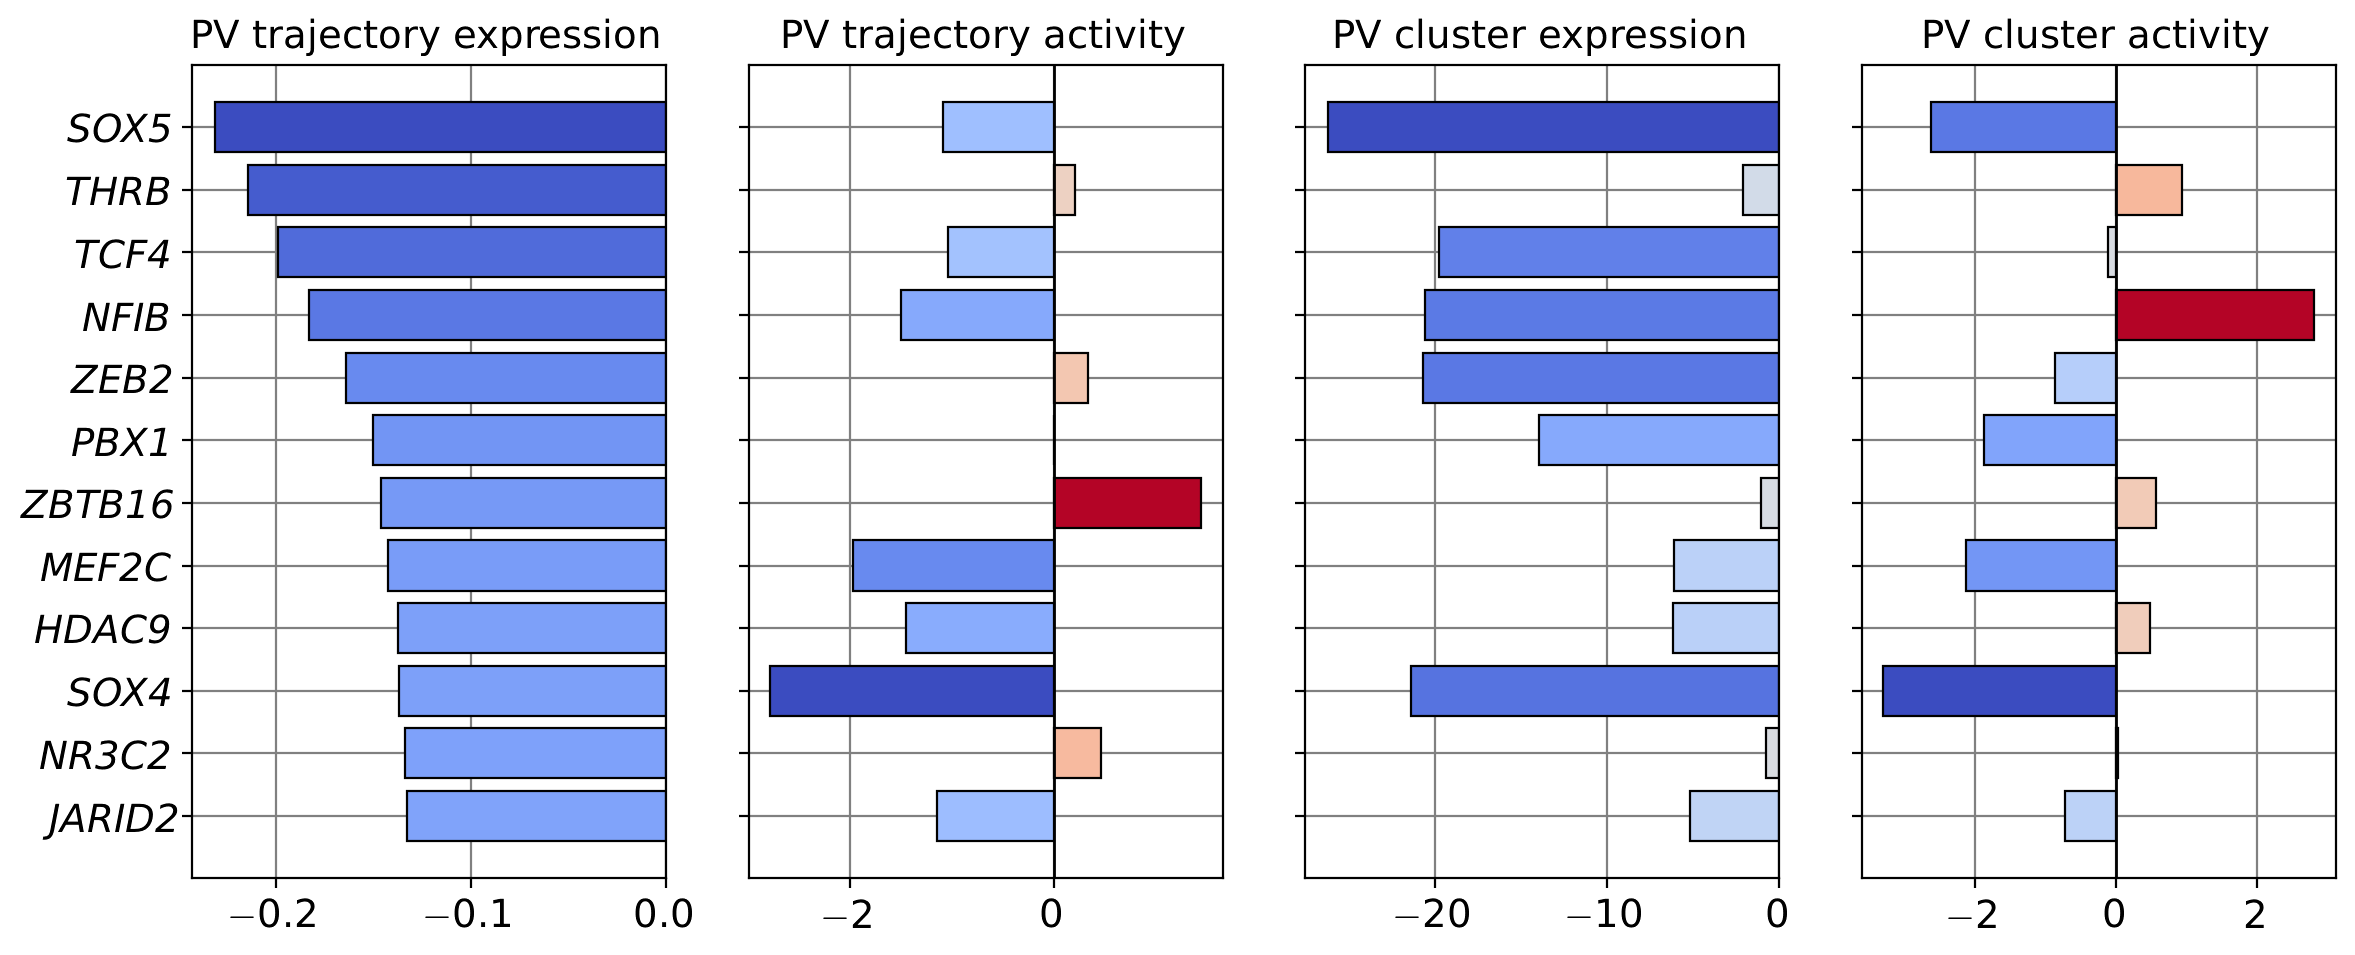

In [123]:
driver_table = pandas.DataFrame(index = driver_df.loc[pv_roadblocks].index)
driver_table["Gene"] = driver_table.index
driver_table["Gene"] = driver_table["Gene"].apply(lambda x: f"\\textit{{{x}}}")
driver_table["PV trajectory expression"] = driver_df.loc[pv_roadblocks, ["15_corr"]]

activity_list = []
for tf in driver_table.index:
    if tf in ulm_driver_df.index:
        activity_list.append(ulm_driver_df.loc[tf, "Activity"])
    else:
        activity_list.append(pandas.NA)
driver_table["PV trajectory activity"] = activity_list

driver_table["PV cluster expression"] = rank_df.loc[driver_table.index, ["scores"]]
dead_end_activity_list = []
for tf in driver_table.index:
    dead_end_activity_list.append(ulm_pv_df.loc[tf, "Activity"])
driver_table["PV cluster activity"] = dead_end_activity_list

# define the columns to be plotted
data_columns = driver_table.columns[1:]

# create a figure with four subplots sharing the y-axis
figure, axes = pyplot.subplots(nrows=1, ncols=len(data_columns), figsize=(12, 5), sharey=True)

# plot each metric in a separate panel
for index in range(len(data_columns)):
    column_name = data_columns[index]
    
    # ensure data is numeric for color mapping
    data_values = driver_table[column_name].astype(float)
    minimum_value = data_values.min()
    maximum_value = data_values.max()
    
    # assign colormap and normalization
    colormap = matplotlib.colormaps["coolwarm"]
    # center the diverging colormap at zero
    if minimum_value < 0 and maximum_value > 0:
        norm = matplotlib.colors.TwoSlopeNorm(vmin=minimum_value, vcenter=0, vmax=maximum_value)
    else:
        norm = matplotlib.colors.TwoSlopeNorm(vmin=min(-1e-10, minimum_value), vcenter=0, vmax=max(1e-10, maximum_value))
            
    # map the normalized values to colors
    bar_colors = colormap(norm(data_values))
    
    # extract data and plot horizontal bars with the calculated colors
    axis = axes[index]
    axis.barh(driver_table["Gene"], data_values, color=bar_colors, edgecolor="black", linewidth=0.8)
    axis.set_title(column_name)
    
    # add a vertical line at zero to highlight positive versus negative values
    axis.axvline(0, color="black", linewidth=1.0)

    axis.grid(True, color="grey")
    axis.set_axisbelow(True)

# invert y-axis so the first gene in the dataframe appears at the top
axes[0].invert_yaxis()

pyplot.tight_layout()

pyplot.savefig("Graphs/pv_roadblock_gene_metrics.png")